# Estimating Discount Sensitivity with Metalearners
### A practical project built on *Causal Inference in Python*, Chapter 7 — "Metalearners"

**Business problem.** You work on the growth team of an online retailer. The
marketing team can send customers a **discount coupon**. The coupon clearly
costs money, and it doesn't affect everyone the same way: some customers buy
a lot more when discounted, others were going to buy anyway (the discount
just eats margin), and a few might even be annoyed by too many promotional
emails. Budget is limited, so we can't discount everyone.

**Goal.** Estimate the **Conditional Average Treatment Effect (CATE)**,
$\tau(x) = E[Y(1) - Y(0) \mid X = x]$, i.e. *how much extra revenue a
discount generates for a customer with characteristics $x$*. Once we have
$\tau(x)$ for every customer, we can prioritize the discount budget toward
the customers who respond the most.

**What this notebook does.**
1. Simulates a realistic dataset: a large **observational/biased** log (like
   the historical data a company already has, where discounts were *not*
   randomly given — e.g., loyal high-spenders got more discounts) plus a
   small **randomized** holdout (like a controlled experiment) used only for
   evaluation — exactly the setup used in the book.
2. Implements, from scratch (no black-box causal libraries), the four
   metalearners from Chapter 7:
   - **T-Learner** — two separate outcome models, one per treatment arm.
   - **X-Learner** — a two-stage learner that corrects the T-Learner's
     *regularization bias* when one treatment arm has much less data.
   - **S-Learner** — a single model with treatment as a feature (works for
     continuous treatments too).
   - **R-Learner / Double Machine Learning** — orthogonalized residual-on-residual
     regression, robust to confounding and less prone to bias toward zero.
3. Evaluates every learner with the **cumulative gain curve** and its AUC
   (the same ranking-based metric the book uses in Chapter 6/7): if a
   learner is good, sorting customers by predicted CATE and progressively
   "treating" the top-ranked ones should accumulate incremental revenue much
   faster than a random ordering.
4. **Reproduces the book's key experiment**: we deliberately create an
   imbalanced dataset (few treated, many untreated) with a nonlinear outcome
   and a *constant* true treatment effect, and show — very concretely — how
   the T-Learner gets the CATE shape wrong (regularization bias) while the
   X-Learner fixes it.
5. Wraps up with a decision guide: which learner to reach for, and when.

> **Note on data.** The original book ships CSV files (`email_obs.csv`,
> `email_rnd.csv`, `discount_data.csv`) that aren't included with this PDF
> excerpt. To keep this notebook fully self-contained and runnable, we
> **simulate data with the same causal structure** the book describes
> (confounded observational data + a small randomized slice for evaluation).
> Because we simulate the data, we also *know the true CATE* — which lets us
> additionally compute the **Precision in Estimating Heterogeneous Effects
> (PEHE)**, i.e. how close each learner's estimate is to the ground truth,
> something you normally can't do with real data.


## 1. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
import statsmodels.api as sm

np.random.seed(123)
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Simulate the data

We mimic the book's marketing-email scenario, but call it a **discount
coupon** to keep a single running example through the notebook (the same
techniques cover the book's binary-treatment email case and its
continuous-treatment discount case).

We generate:

- `data_biased` — a **large historical/observational** dataset (300,000
  rows). Discounts were **not** randomized: customers with higher `tenure`
  and higher past spend (`age`-correlated loyalty proxy) were more likely to
  receive a discount. This is realistic (marketing teams target loyal or
  high-value customers) and it is exactly the kind of **confounding** that
  makes naive comparisons misleading.
- `data_rnd` — a **small randomized** dataset (10,000 rows) where the
  discount was assigned by a coin flip. We only use this for **evaluation**,
  never for training — just like the book's `data_rnd`, which stands in for
  a costly, hard-to-get A/B test.

The true treatment effect is **heterogeneous**: customers with high `tenure`
and low `recency` (i.e., engaged repeat customers) respond more to a
discount than brand-new or dormant ones. We hard-code this so we can check
every learner against ground truth later.


In [2]:
def simulate_customers(n, seed):
    rng = np.random.default_rng(seed)

    age = rng.normal(40, 12, n).clip(18, 80)
    tenure = rng.exponential(24, n).clip(0, 120)         # months as customer
    recency = rng.exponential(20, n).clip(0, 180)        # days since last purchase
    past_purchases = rng.poisson(5 + tenure / 12, n)     # loyalty proxy
    avg_basket = rng.gamma(4, 15, n)                     # avg $ per order

    X = pd.DataFrame(dict(
        age=age,
        tenure=tenure,
        recency=recency,
        past_purchases=past_purchases,
        avg_basket=avg_basket,
    ))
    return X


def assign_treatment_biased(X, rng):
    # Marketing targets loyal, recently-engaged, higher-spend customers
    # -> classic confounding: the same traits also predict higher baseline spend.
    logit = (
        -1.2
        + 0.03 * X["tenure"]
        - 0.015 * X["recency"]
        + 0.10 * X["past_purchases"]
        + 0.01 * X["avg_basket"]
    )
    p = 1 / (1 + np.exp(-logit))
    p = p.clip(0.02, 0.98)
    T = rng.binomial(1, p)
    return T, p


def true_cate(X):
    # Engaged, loyal customers (long tenure, low recency) respond more to a discount.
    effect = (
        10
        + 0.35 * X["tenure"]
        - 0.20 * X["recency"]
        + 1.20 * X["past_purchases"]
    )
    return effect.clip(lower=0)


def simulate_outcome(X, T, rng):
    tau = true_cate(X)
    baseline = (
        20
        + 1.8 * X["avg_basket"]
        + 0.5 * X["past_purchases"]
        - 0.05 * X["recency"]
        + 0.10 * X["tenure"]
    )
    noise = rng.normal(0, 15, len(X))
    Y = baseline + T * tau + noise
    return Y.clip(lower=0), tau


rng = np.random.default_rng(123)

# --- Large biased/observational dataset ---
X_biased = simulate_customers(300_000, seed=1)
T_biased, ps_true = assign_treatment_biased(X_biased, rng)
Y_biased, tau_biased = simulate_outcome(X_biased, T_biased, rng)
data_biased = X_biased.assign(discount=T_biased, next_mnth_revenue=Y_biased)

# --- Small randomized dataset (holdout, used ONLY for evaluation) ---
X_rnd = simulate_customers(10_000, seed=2)
T_rnd = rng.binomial(1, 0.5, len(X_rnd))
Y_rnd, tau_rnd_true = simulate_outcome(X_rnd, T_rnd, rng)
data_rnd = X_rnd.assign(discount=T_rnd, next_mnth_revenue=Y_rnd, true_cate=tau_rnd_true)

print(len(data_biased), len(data_rnd))
data_rnd.head()


300000 10000


,age,tenure,recency,past_purchases,avg_basket,discount,next_mnth_revenue,true_cate
0,42.268641,8.959703,25.434522,7,38.328716,1,128.952131,16.448992
1,33.727019,4.392749,8.873616,7,24.462097,0,81.369812,18.162739
2,35.043237,1.466926,14.890135,6,45.689996,1,110.848290,14.735397
3,18.000000,10.048702,20.195184,4,20.406423,1,46.770494,14.278009
4,61.596489,11.239483,0.012187,6,39.740179,0,104.423008,21.131381


A quick sanity check: in the **biased** data, does a naive comparison of
treated vs. untreated averages overstate the effect (because loyal customers
both get more discounts *and* spend more anyway)?


In [3]:
naive_biased = (
    data_biased.groupby("discount")["next_mnth_revenue"].mean()
)
naive_rnd = (
    data_rnd.groupby("discount")["next_mnth_revenue"].mean()
)

print("Naive diff-in-means, BIASED data:", naive_biased[1] - naive_biased[0])
print("Naive diff-in-means, RANDOMIZED data (unbiased ATE estimate):", naive_rnd[1] - naive_rnd[0])
print("True ATE (simulation ground truth):", true_cate(pd.concat([X_biased, X_rnd])).mean())


Naive diff-in-means, BIASED data: 41.939113626685895
Naive diff-in-means, RANDOMIZED data (unbiased ATE estimate): 22.087542440902126
True ATE (simulation ground truth): 22.731808338209735


As expected, the naive comparison on **biased** data overstates the effect
relative to the randomized benchmark — this is exactly the confounding
problem metalearners need to survive. Everything below is trained **only**
on `data_biased`, and evaluated **only** on `data_rnd` (which the model
never sees during training) — mirroring the book's train/test split.


In [4]:
y = "next_mnth_revenue"
T = "discount"
X = ["age", "tenure", "recency", "past_purchases", "avg_basket"]

train, test = data_biased, data_rnd
print("Covariates:", X)


Covariates: ['age', 'tenure', 'recency', 'past_purchases', 'avg_basket']


## 3. Evaluation tooling: the cumulative gain curve

Because we don't observe individual treatment effects (the fundamental
problem of causal inference), we can't compute an $R^2$ against "true CATE"
on real-world data. The book's trick (Chapter 6) is a **ranking metric**:
if a model's CATE predictions are good, sorting customers from *highest*
predicted effect to *lowest* and cumulatively "treating" them (using the
randomized `data_rnd` to get unbiased incremental-revenue estimates at each
cutoff) should front-load the total incremental revenue.

We implement the cumulative gain curve and its AUC relative to the random
(diagonal) baseline. Since we *also* know the ground-truth CATE in this
simulation, we add a second, complementary metric: **PEHE**
($\sqrt{E[(\hat\tau(x)-\tau(x))^2]}$), the precision in estimating
heterogeneous effects. Cumulative gain tells us "did we rank customers
correctly?"; PEHE tells us "were the actual numbers right?"


In [5]:
def cumulative_gain_curve(df, prediction, y, t, steps=100):
    size = len(df)
    ordered = df.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(1, size, max(1, size // steps))) + [size]

    gains = []
    for rows in n_rows:
        subset = ordered.head(rows)
        treated = subset.query(f"{t}==1")
        control = subset.query(f"{t}==0")
        if len(treated) == 0 or len(control) == 0:
            gains.append(0)
            continue
        effect = treated[y].mean() - control[y].mean()
        gains.append(effect * rows / size)

    return np.array(n_rows) / size * 100, np.array(gains)


def auc_relative_to_baseline(x_pct, gains):
    baseline = np.linspace(0, gains[-1], len(gains))
    trapz_fn = getattr(np, "trapezoid", None) or np.trapz
    return trapz_fn(gains - baseline, x_pct)


def plot_cumulative_gain(df, prediction, y, t, title, ax=None):
    x_pct, gains = cumulative_gain_curve(df, prediction, y, t)
    auc = auc_relative_to_baseline(x_pct, gains)
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(x_pct, gains, label=f"AUC: {auc:.2f}")
    ax.plot([0, 100], [0, gains[-1]], "--", color="gray", label="Baseline")
    ax.set_title(title)
    ax.set_xlabel("% of customers targeted (sorted by predicted CATE)")
    ax.set_ylabel("Cumulative gain ($)")
    ax.legend()
    return auc


def pehe(true_effect, pred_effect):
    return float(np.sqrt(np.mean((np.asarray(true_effect) - np.asarray(pred_effect)) ** 2)))


## 4. T-Learner

Fit one outcome model per treatment arm:

$$\hat\mu_0(x) \approx E[Y\mid T=0, X], \qquad \hat\mu_1(x) \approx E[Y\mid T=1, X]$$

$$\hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$$

Simple, and a good first thing to try — but as the book explains, it can
suffer from **regularization bias** when one arm has much less data than
the other, because the sparser model tends to self-regularize into an
overly simple shape.


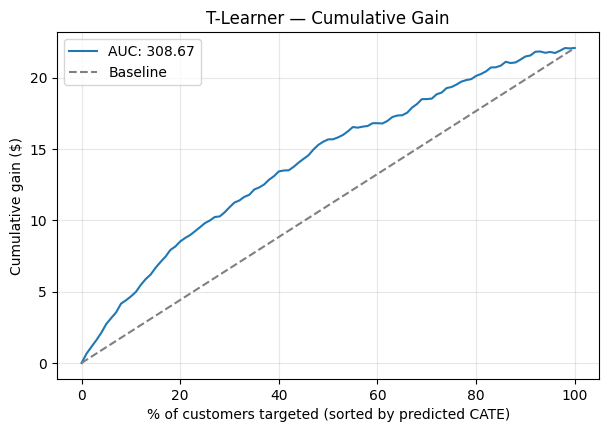

T-Learner PEHE: 3.3408698322052883


In [6]:
np.random.seed(123)
m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y])

t_learner_pred = test.assign(cate=m1.predict(test[X]) - m0.predict(test[X]))

auc_t = plot_cumulative_gain(t_learner_pred, "cate", y, T, "T-Learner — Cumulative Gain")
plt.show()
print("T-Learner PEHE:", pehe(test["true_cate"], t_learner_pred["cate"]))


## 5. X-Learner

Two stages plus a propensity-score model:

1. Fit $\hat\mu_0$, $\hat\mu_1$ exactly like the T-Learner.
2. Impute the missing potential outcome for every unit and form
   *individual* effect estimates:
   $$\hat\tau(X, T{=}0) = \hat\mu_1(X) - Y_{T=0}, \qquad
     \hat\tau(X, T{=}1) = Y_{T=1} - \hat\mu_0(X)$$
3. Fit two more models, $\hat\mu_{\tau 0}$ and $\hat\mu_{\tau 1}$, to
   predict those imputed effects from $X$.
4. Combine them with the propensity score $\hat e(x)$:
   $$\hat\tau(x) = \hat\mu_{\tau 0}(x)\,\hat e(x) + \hat\mu_{\tau 1}(x)\,(1-\hat e(x))$$

The propensity score automatically **down-weights the CATE estimate that
came from the model trained on the smaller/noisier treatment arm** — this
is precisely how the X-Learner corrects the T-Learner's regularization
bias. We'll see this vividly in Section 8.


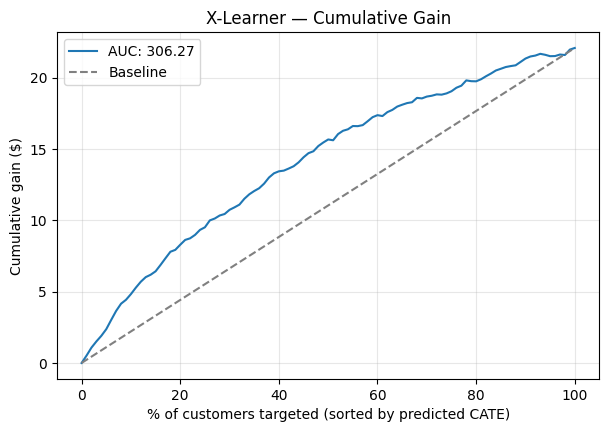

X-Learner PEHE: 1.7146693987806236


In [7]:
np.random.seed(123)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(train[X], train[T])

train_t0 = train.query(f"{T}==0")
train_t1 = train.query(f"{T}==1")

m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)
m0.fit(train_t0[X], train_t0[y])
m1.fit(train_t1[X], train_t1[y])

# Stage 2: impute effects, fit models on them
tau_hat_0 = m1.predict(train_t0[X]) - train_t0[y]
tau_hat_1 = train_t1[y] - m0.predict(train_t1[X])

m_tau_0 = LGBMRegressor(verbosity=-1)
m_tau_1 = LGBMRegressor(verbosity=-1)
m_tau_0.fit(train_t0[X], tau_hat_0)
m_tau_1.fit(train_t1[X], tau_hat_1)

ps_test = ps_model.predict_proba(test[X])[:, 1]
x_learner_pred = test.assign(
    cate=ps_test * m_tau_0.predict(test[X]) + (1 - ps_test) * m_tau_1.predict(test[X])
)

auc_x = plot_cumulative_gain(x_learner_pred, "cate", y, T, "X-Learner — Cumulative Gain")
plt.show()
print("X-Learner PEHE:", pehe(test["true_cate"], x_learner_pred["cate"]))


## 6. S-Learner

A **single** model with treatment as a feature: $\hat\mu(x, t) \approx
E[Y\mid T{=}t, X{=}x]$. For a binary treatment, the CATE is just the
counterfactual difference:

$$\hat\tau(x) = \hat\mu(x, T{=}1) - \hat\mu(x, T{=}0)$$

It's the simplest learner, supports continuous treatments naturally, and is
a solid default — but (per the book) it tends to **bias the treatment
effect toward zero**, especially when the treatment signal is weak relative
to the other covariates, because a regularized model can end up
under-using the treatment feature.


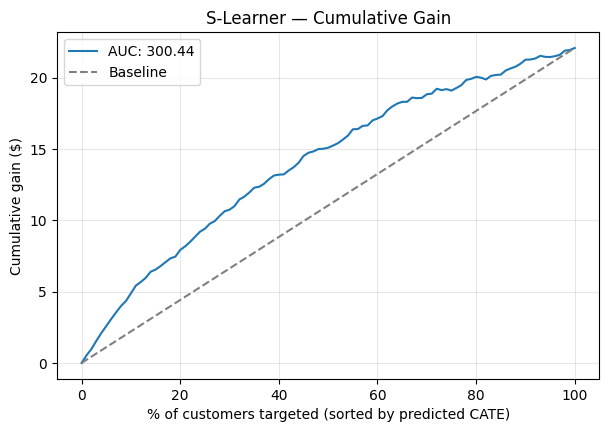

S-Learner PEHE: 2.0475520196674695


In [8]:
np.random.seed(123)
s_learner = LGBMRegressor(verbosity=-1)
s_learner.fit(train[X + [T]], train[y])

test_t1 = test[X].assign(**{T: 1})
test_t0 = test[X].assign(**{T: 0})

s_learner_pred = test.assign(
    cate=s_learner.predict(test_t1) - s_learner.predict(test_t0)
)

auc_s = plot_cumulative_gain(s_learner_pred, "cate", y, T, "S-Learner — Cumulative Gain")
plt.show()
print("S-Learner PEHE:", pehe(test["true_cate"], s_learner_pred["cate"]))


## 7. R-Learner / Double Machine Learning

The idea (Double/Debiased ML, Chernozhukov et al.): remove the influence of
$X$ from *both* $Y$ and $T$ via out-of-fold ML residuals, then regress the
residuals against each other. For **heterogeneous** effects, minimizing the
R-loss

$$\hat L_n(\tau(x)) = \frac{1}{n}\sum_i \big((Y_i - \hat\mu_y(X_i)) - \tau(X_i)(T_i - \hat\mu_t(X_i))\big)^2$$

is algebraically equivalent to fitting a normal regression model on the
transformed target $Y^* = \tilde Y / \tilde T$, weighted by $\tilde T^2$
— exactly the same "transformed outcome" trick from the book's evaluation
chapter, now used for *training*. This learner directly outputs CATE
predictions and, because of the out-of-fold residualization, is fairly
robust to confounding without needing a full second imputation stage like
the X-Learner.


In [9]:
np.random.seed(123)

debias_m = LGBMRegressor(verbosity=-1)   # predicts T from X
denoise_m = LGBMRegressor(verbosity=-1)  # predicts Y from X

t_res = train[T] - cross_val_predict(debias_m, train[X], train[T], cv=5)
y_res = train[y] - cross_val_predict(denoise_m, train[X], train[y], cv=5)

# Sanity check: on this data the treatment is confounded, so the naive
# ATE and the orthogonalized ATE should differ.
print("Naive ATE (biased data):", naive_biased[1] - naive_biased[0])
print("Double-ML ATE estimate:", sm.OLS(y_res, t_res).fit().params.iloc[0])
print("True ATE:", true_cate(pd.concat([X_biased, X_rnd])).mean())


Naive ATE (biased data): 41.939113626685895
Double-ML ATE estimate: 20.358509372120313
True ATE: 22.731808338209735


The debiased ATE estimate should land much closer to the true ATE than the naive comparison. Now let's get CATE estimates by fitting the transformed-target regression:

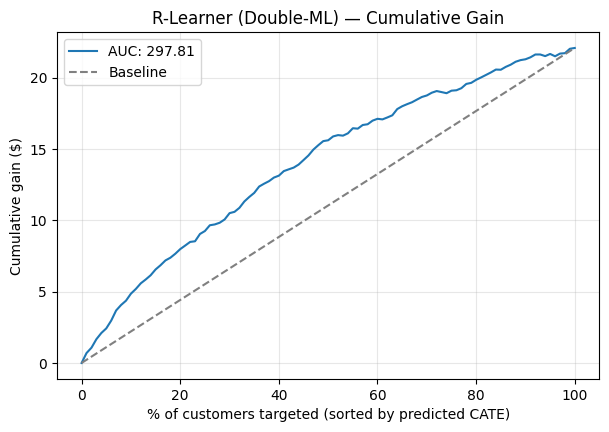

R-Learner PEHE: 1.7003226846610267


In [10]:
np.random.seed(123)

y_star = y_res / t_res
w = t_res ** 2

r_learner = LGBMRegressor(verbosity=-1)
r_learner.fit(train[X], y_star, sample_weight=w)

r_learner_pred = test.assign(cate=r_learner.predict(test[X]))

auc_r = plot_cumulative_gain(r_learner_pred, "cate", y, T, "R-Learner (Double-ML) — Cumulative Gain")
plt.show()
print("R-Learner PEHE:", pehe(test["true_cate"], r_learner_pred["cate"]))


## 8. Head-to-head comparison

Let's put all four learners on the same cumulative gain plot and compare
their PEHE against the ground-truth CATE (only possible here because we
simulated the data).


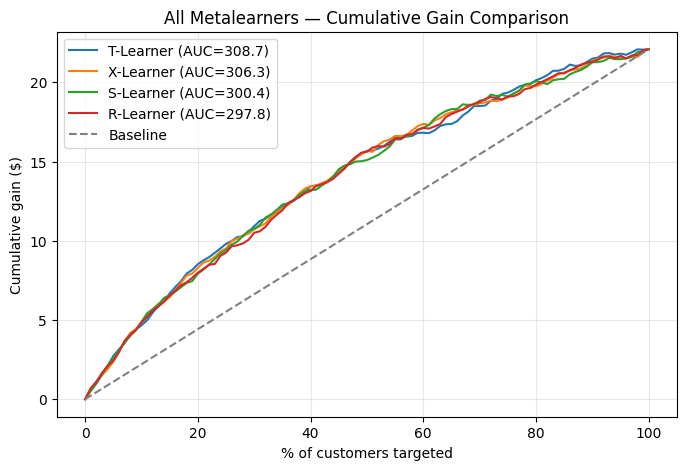

,AUC,PEHE
R-Learner,297.807711,1.700323
X-Learner,306.274007,1.714669
S-Learner,300.443619,2.047552
T-Learner,308.666157,3.340870


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
results = {}
for name, df, col in [
    ("T-Learner", t_learner_pred, "cate"),
    ("X-Learner", x_learner_pred, "cate"),
    ("S-Learner", s_learner_pred, "cate"),
    ("R-Learner", r_learner_pred, "cate"),
]:
    x_pct, gains = cumulative_gain_curve(df, col, y, T)
    auc = auc_relative_to_baseline(x_pct, gains)
    results[name] = dict(
        AUC=auc,
        PEHE=pehe(test["true_cate"], df[col]),
    )
    ax.plot(x_pct, gains, label=f"{name} (AUC={auc:.1f})")

ax.plot([0, 100], [0, gains[-1]], "--", color="gray", label="Baseline")
ax.set_xlabel("% of customers targeted")
ax.set_ylabel("Cumulative gain ($)")
ax.set_title("All Metalearners — Cumulative Gain Comparison")
ax.legend()
plt.show()

pd.DataFrame(results).T.sort_values("PEHE")


On this **balanced** dataset (roughly comparable numbers of treated and
untreated customers), all four learners should land in a similar
ballpark — matching what the book observes with its own balanced email
dataset ("the T-learner and X-learner have pretty similar performance...
this dataset probably doesn't run into the type of problem the X-learner
tries to solve"). The real differences show up under **imbalance**, which
we simulate next.


## 9. Reproducing the book's key experiment: regularization bias under imbalance

The book's central illustration (Figure in the T-Learner section) is this:
when treated units are **scarce** relative to control units, and the
*outcome* is nonlinear in $X$ while the *true treatment effect is constant*,
a T-Learner's $\hat\mu_1$ model gets over-regularized (too little data to
justify a complex fit) while $\hat\mu_0$ correctly captures the
nonlinearity — and their difference produces a CATE estimate that is
**wrong and non-constant**, even though the true CATE is flat.

Let's build that exact scenario: 1-D covariate $x$, nonlinear baseline
$\mu_0(x)$, and a constant true treatment effect of 1. Only 3% of units are
treated.


In [12]:
def simulate_imbalanced(n=4000, treat_share=0.03, seed=1):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 1, n)
    T = rng.binomial(1, treat_share, n)

    mu0 = 0.4 * np.exp(-30 * x ** 2)          # sharp bump around x=0
    tau_true = np.ones(n)                     # CONSTANT true effect = 1
    noise = rng.normal(0, 0.05, n)

    Y = mu0 + T * tau_true + noise
    return pd.DataFrame(dict(x=x, T=T, Y=Y, tau_true=tau_true))


imb = simulate_imbalanced()
imb_train, imb_test = imb.iloc[: len(imb) // 2], imb.iloc[len(imb) // 2:]
print("Treated units in training set:", imb_train['T'].sum(), "/", len(imb_train))


Treated units in training set: 60 / 2000


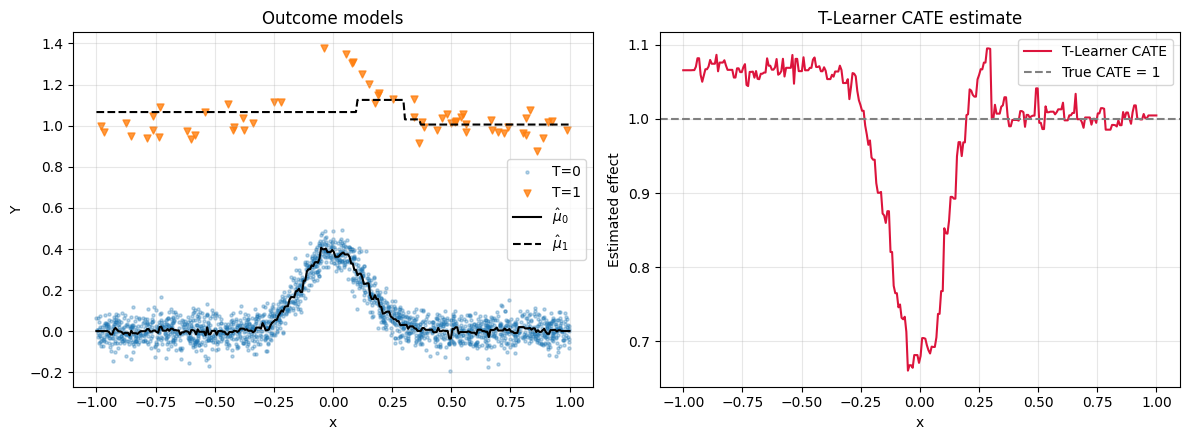

In [13]:
from lightgbm import LGBMRegressor as LGBM

# T-Learner, deliberately using the SAME hyperparameters for both arms
# (min_child_samples forces self-regularization when data is scarce)
np.random.seed(123)
m0_imb = LGBM(min_child_samples=25, verbosity=-1)
m1_imb = LGBM(min_child_samples=25, verbosity=-1)
m0_imb.fit(imb_train.query("T==0")[["x"]], imb_train.query("T==0")["Y"])
m1_imb.fit(imb_train.query("T==1")[["x"]], imb_train.query("T==1")["Y"])

grid = pd.DataFrame({"x": np.linspace(-1, 1, 300)})
mu0_hat = m0_imb.predict(grid)
mu1_hat = m1_imb.predict(grid)
t_learner_cate_imb = mu1_hat - mu0_hat

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(imb_train.query("T==0")["x"], imb_train.query("T==0")["Y"], s=5, alpha=0.3, label="T=0")
axes[0].scatter(imb_train.query("T==1")["x"], imb_train.query("T==1")["Y"], s=25, alpha=0.8, label="T=1", marker="v")
axes[0].plot(grid["x"], mu0_hat, color="black", label=r"$\hat\mu_0$")
axes[0].plot(grid["x"], mu1_hat, "--", color="black", label=r"$\hat\mu_1$")
axes[0].legend(); axes[0].set_title("Outcome models"); axes[0].set_xlabel("x"); axes[0].set_ylabel("Y")

axes[1].plot(grid["x"], t_learner_cate_imb, color="crimson", label="T-Learner CATE")
axes[1].axhline(1.0, color="gray", linestyle="--", label="True CATE = 1")
axes[1].legend(); axes[1].set_title("T-Learner CATE estimate"); axes[1].set_xlabel("x"); axes[1].set_ylabel("Estimated effect")
plt.tight_layout()
plt.show()


Just like in the book: $\hat\mu_1$ (the sparse, treated-only model) is
essentially forced flat by `min_child_samples`, while $\hat\mu_0$ (fit on
abundant control data) correctly captures the bump — so the T-Learner's
CATE estimate **incorrectly dips** exactly where the nonlinearity is,
instead of staying flat at the true value of 1.

Now the X-Learner, on the *same* data:


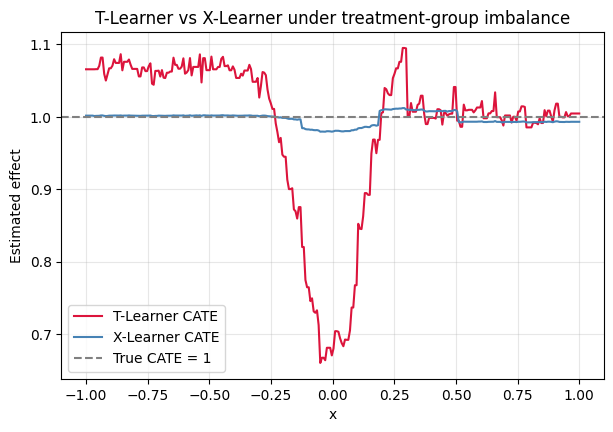

T-Learner PEHE (imbalanced scenario): 0.10870946838185029
X-Learner PEHE (imbalanced scenario): 0.008589909090666826


In [14]:
np.random.seed(123)

ps_model_imb = LogisticRegression(max_iter=1000)
ps_model_imb.fit(imb_train[["x"]], imb_train["T"])

t0 = imb_train.query("T==0")
t1 = imb_train.query("T==1")

tau_hat_0_imb = m1_imb.predict(t0[["x"]]) - t0["Y"]
tau_hat_1_imb = t1["Y"] - m0_imb.predict(t1[["x"]])

m_tau0 = LGBM(verbosity=-1)
m_tau1 = LGBM(verbosity=-1)
m_tau0.fit(t0[["x"]], tau_hat_0_imb)
m_tau1.fit(t1[["x"]], tau_hat_1_imb)

ps_grid = ps_model_imb.predict_proba(grid)[:, 1]
x_learner_cate_imb = ps_grid * m_tau0.predict(grid) + (1 - ps_grid) * m_tau1.predict(grid)

fig, ax = plt.subplots()
ax.plot(grid["x"], t_learner_cate_imb, color="crimson", label="T-Learner CATE")
ax.plot(grid["x"], x_learner_cate_imb, color="steelblue", label="X-Learner CATE")
ax.axhline(1.0, color="gray", linestyle="--", label="True CATE = 1")
ax.legend()
ax.set_title("T-Learner vs X-Learner under treatment-group imbalance")
ax.set_xlabel("x"); ax.set_ylabel("Estimated effect")
plt.show()

print("T-Learner PEHE (imbalanced scenario):", pehe(imb_test["tau_true"],
      np.interp(imb_test["x"], grid["x"], t_learner_cate_imb)))
print("X-Learner PEHE (imbalanced scenario):", pehe(imb_test["tau_true"],
      np.interp(imb_test["x"], grid["x"], x_learner_cate_imb)))


The X-Learner's curve should sit **much closer to the flat, true CATE of
1** than the T-Learner's dip — and its PEHE should be visibly lower. This
is the propensity-score weighting doing exactly what the book describes:
because treated units are so rare, $\hat e(x)$ is small, so the (wrong)
$\hat\mu_{\tau 0}$ estimate gets down-weighted and the (correct)
$\hat\mu_{\tau 1}$ estimate dominates.


## 10. Turning this into a business decision: budget-constrained targeting

Back on the main (balanced) dataset — suppose marketing can only afford to
discount the **top 20%** of customers by predicted CATE. Let's translate the
best learner's cumulative gain curve into a concrete revenue estimate for
that policy, versus targeting randomly.


In [15]:
best_learner_name = pd.DataFrame(results).T.sort_values("PEHE").index[0]
best_learner_pred = {
    "T-Learner": t_learner_pred, "X-Learner": x_learner_pred,
    "S-Learner": s_learner_pred, "R-Learner": r_learner_pred,
}[best_learner_name]

x_pct, gains = cumulative_gain_curve(best_learner_pred, "cate", y, T)
gain_at_20pct = np.interp(20, x_pct, gains)
random_gain_at_20pct = gains[-1] * 0.20

print(f"Best learner on this dataset: {best_learner_name}")
print(f"Estimated incremental revenue from discounting top 20% (targeted): ${gain_at_20pct:,.0f} per customer-unit of gain")
print(f"Estimated incremental revenue from discounting a random 20%:        ${random_gain_at_20pct:,.0f}")
print(f"Uplift from targeting vs. random: {100*(gain_at_20pct/random_gain_at_20pct - 1):.1f}%")


Best learner on this dataset: R-Learner
Estimated incremental revenue from discounting top 20% (targeted): $8 per customer-unit of gain
Estimated incremental revenue from discounting a random 20%:        $4
Uplift from targeting vs. random: 80.7%


This is the payoff of the whole exercise: instead of blasting discounts to
everyone (expensive) or randomly (wasteful), the CATE model lets marketing
concentrate the budget on the customers who will actually respond —
recovering most of the achievable incremental revenue from a fraction of
the spend.


## 11. Key takeaways / decision guide

| Learner | How it works | Strengths | Watch out for |
|---|---|---|---|
| **T-Learner** | One model per treatment arm, subtract predictions | Simple, good default with balanced, plentiful data | Regularization bias when treatment groups are imbalanced |
| **X-Learner** | T-Learner + imputed-effect stage + propensity-weighted combination | Corrects regularization bias; great with imbalanced arms | More moving parts; needs a decent propensity model |
| **S-Learner** | Single model, treatment as a feature | Simplest; supports continuous treatment natively; robust when treatment signal is strong | Biases effect toward zero; can drop a weak treatment signal entirely under heavy regularization |
| **R-Learner (Double-ML)** | Residualize Y and T out-of-fold, regress residuals (weighted) | Directly outputs CATE; robust to confounding via orthogonalization; no imputation step | Needs good nuisance models ($\hat\mu_y$, $\hat\mu_t$) and out-of-fold prediction to avoid overfitting bias |

**Practical rules of thumb (from this notebook and the book):**

- Always evaluate on a **held-out randomized sample** if you have one — it's
  the only way to trust the cumulative gain curve.
- If treatment and control groups are **roughly balanced**, the T-Learner is
  a perfectly reasonable, simple starting point.
- If one treatment arm is **much smaller** than the other, prefer the
  **X-Learner** (or at least check whether the T-Learner's CATE curve shows
  the tell-tale bias where the outcome is nonlinear).
- If your treatment is **continuous**, start with the **S-Learner** — it's
  the only one of the four that handles this natively without extra
  machinery — but be alert to it shrinking the effect toward zero.
- If you're worried about **confounding** and want an estimator with
  theoretical guarantees, use the **R-Learner / Double-ML**, making sure to
  use out-of-fold (cross-fitted) residuals to avoid overfitting bias.
- All of the above rely on the **unconfoundedness assumption**: your
  covariates $X$ must contain every relevant confounder. No metalearner can
  fix a mis-specified causal problem — this determines whether the whole
  exercise is trustworthy far more than which learner you pick.
